In [8]:
import numpy as np
import os
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
from src.safetymaps import *
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


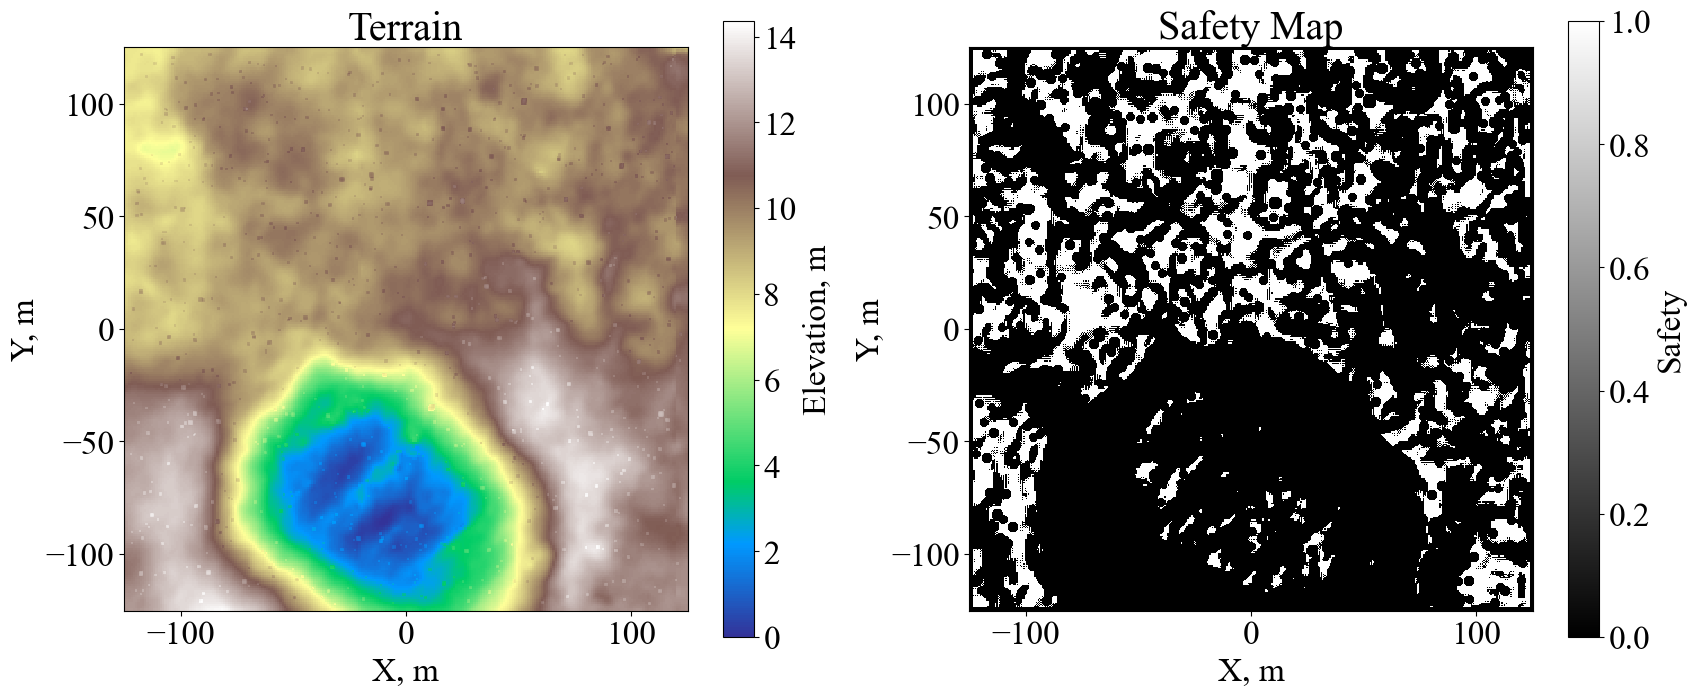

In [46]:
# visualize terrain and safety map
data_dir = "../saved/sfmap_shd_based"

dem_data = np.load(os.path.join(data_dir, "dem_data.npz"))
dem, xx, yy = dem_data["dem"], dem_data["xx"], dem_data["yy"]
dem -= np.min(dem)

safety_map = np.load(os.path.join(data_dir, "sfmap_data_truth.npz"))["site_safe"]

# Plotting
plt.rcParams.update({'font.size': 24})
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# Safety map
c1 = ax[1].pcolormesh(xx, yy, safety_map, cmap='gray')
ax[1].set_title("Safety Map")
ax[1].set_xlabel("X, m")
ax[1].set_ylabel("Y, m")
ax[1].set_aspect('equal')
plt.colorbar(c1, ax=ax[1], label='Safety', shrink=0.8)

# Terrain map
c2 = ax[0].pcolormesh(xx, yy, dem, cmap='terrain')
ax[0].set_title("Terrain")
ax[0].set_xlabel("X, m")
ax[0].set_ylabel("Y, m")
ax[0].set_aspect('equal')
plt.colorbar(c2, ax=ax[0], label='Elevation, m', shrink=0.8)

#plt.show()
# save
fig.savefig(os.path.join(data_dir, "terrain_sfmap.png"), bbox_inches='tight')

c:\Users\ktomita3\Documents\001_workspace\learning-hda-reachability\dev\..\src\safetymaps.py:431: RuntimeWarning: invalid value encountered in cast
  original_image = Image.fromarray(np.uint8(sfmap * 255))


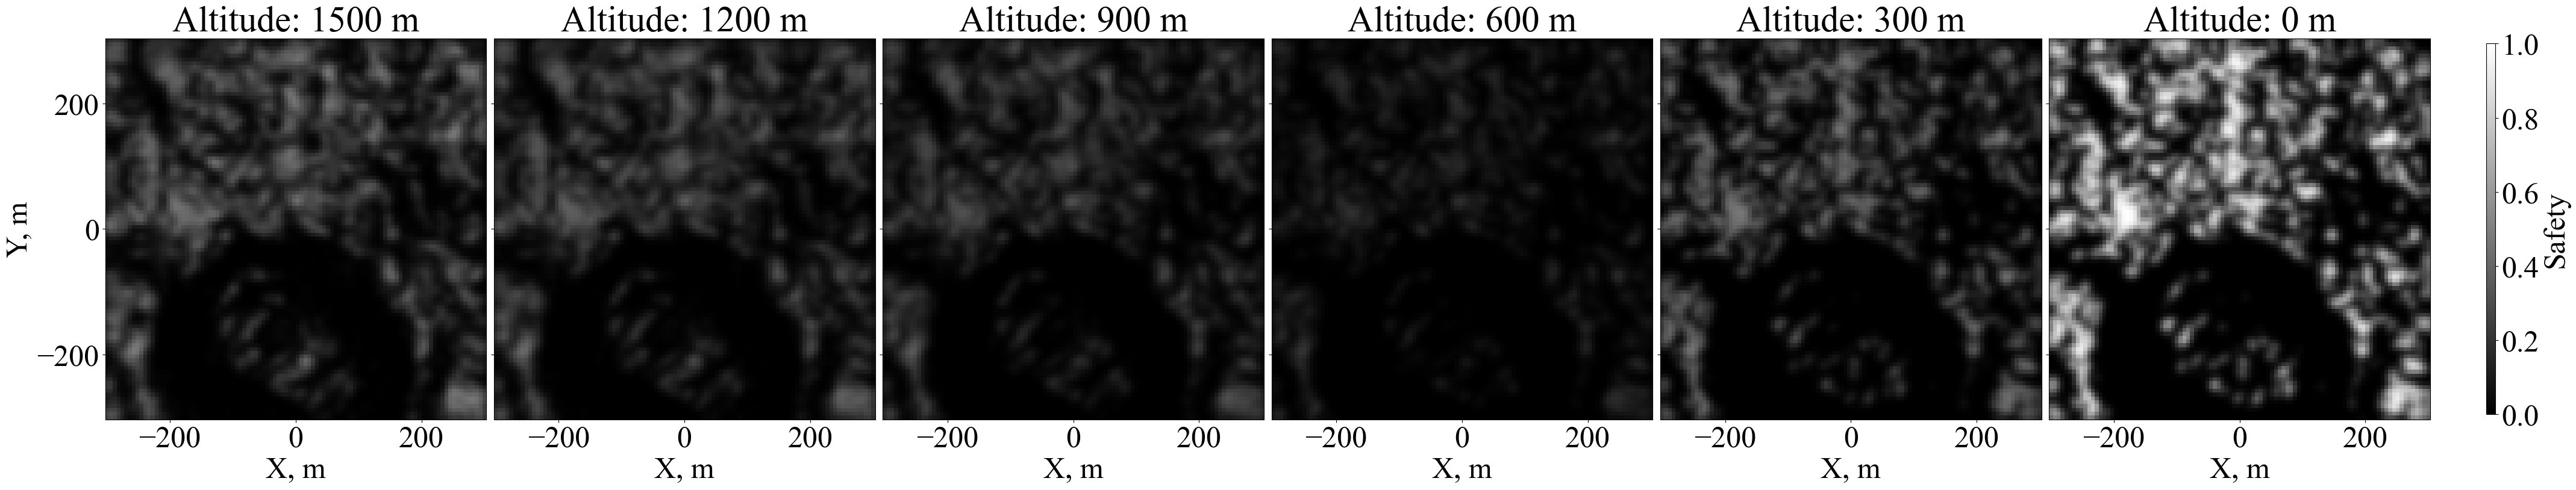

In [47]:
# visualize safety maps in one plot
n = 6
alt_list = np.linspace(0, 1500, n)
npoints = 100

#sfmap_model = StaticSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=npoints)
#sfmap_model = DynamicSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=npoints, relative_path="..")
#sfmap_model = StaticNoisedSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=npoints)
#sfmap_model = DesignedSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=npoints, n_hazards=[50, 50, 400, 2000, 2000], hazard_sizes=[14, 12,  8, 5, 2])
sfmap_model = DynamicSafetyMap2(x_range=(-300, 300), y_range=(-300, 300), npoints=npoints, relative_path='../')

sfmap_list = []

for alt in alt_list:
    sfmap = sfmap_model.get_sfmap(alt)
    sfmap = sfmap.reshape((npoints, npoints, 3))
    sfmap_list.append(sfmap)

# make font bigger
plt.rcParams.update({'font.size': 6 * n})

fig, ax = plt.subplots(1, n, figsize=(10 * n, 10), sharex=True, sharey=True)
for i in range(n):
    ax_idx = n - i - 1  # This ensures that the plots are in the correct order
    c = ax[ax_idx].pcolormesh(sfmap_list[i][:, :, 0], sfmap_list[i][:, :, 1], sfmap_list[i][:, :, 2], cmap='gray', vmin=0, vmax=1)
    ax[ax_idx].set_title(f"Altitude: {alt_list[i]:.0f} m")
    ax[ax_idx].set_xlabel("X, m")
    
    if ax_idx == 0:
        ax[ax_idx].set_ylabel("Y, m")
    else:
        ax[ax_idx].set_ylabel("")  # Remove y-label for all but the first plot
    
    ax[ax_idx].set_aspect('equal')

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.02, hspace=0)

# Add colorbar on the right outside the subplots
cbar = fig.colorbar(c, ax=ax, orientation='vertical', shrink=0.8, aspect=40, pad=0.02)
cbar.set_label('Safety')

#plt.show()

# save
fig.savefig(os.path.join(data_dir, "sfmap_altitude.png"), bbox_inches='tight')

c:\Users\ktomita3\Documents\001_workspace\learning-hda-reachability\dev\..\src\safetymaps.py:431: RuntimeWarning: invalid value encountered in cast
  original_image = Image.fromarray(np.uint8(sfmap * 255))


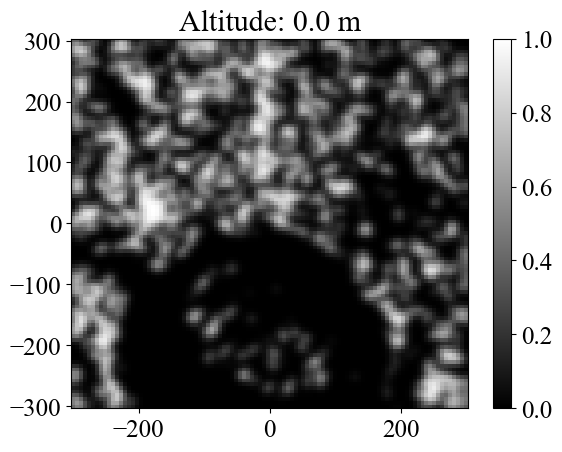

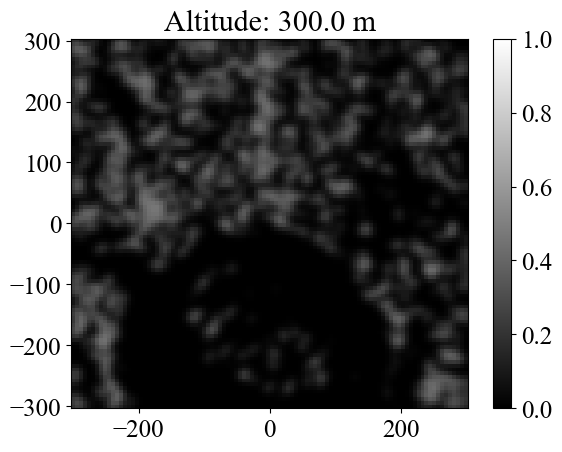

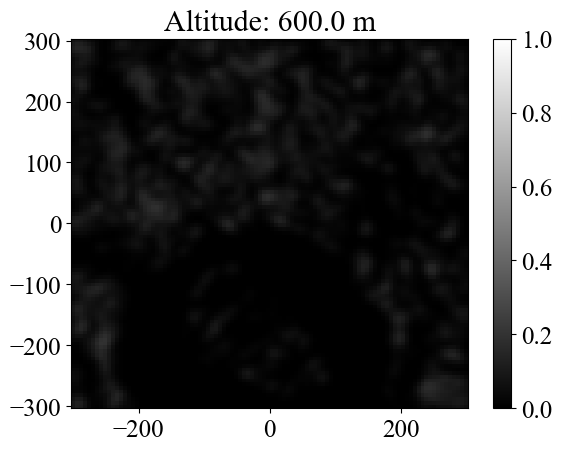

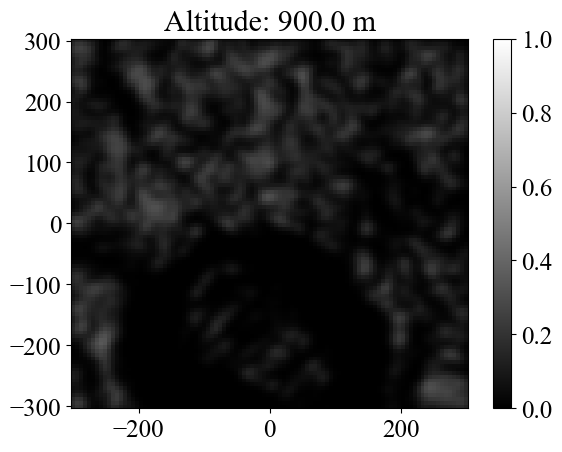

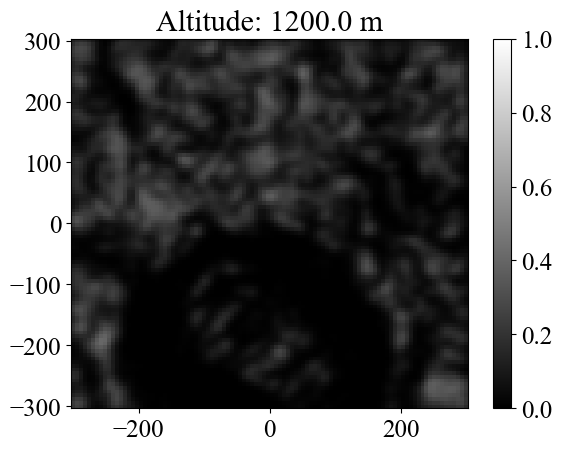

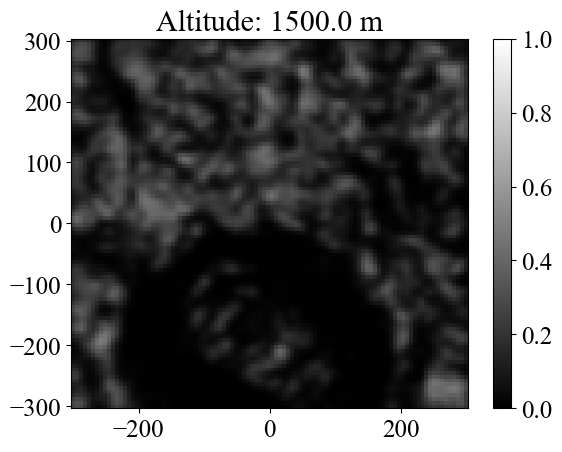

In [13]:
alt_list = np.linspace(0, 1500, 6)
npoints = 100

#sfmap_model = StaticSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=npoints)
#sfmap_model = DynamicSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=npoints, relative_path="..")
#sfmap_model = StaticNoisedSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=npoints)
#sfmap_model = DesignedSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=npoints, n_hazards=[50, 50, 400, 2000, 2000], hazard_sizes=[14, 12,  8, 5, 2])
sfmap_model = DynamicSafetyMap2(x_range=(-300, 300), y_range=(-300, 300), npoints=npoints, relative_path='../')

for alt in alt_list:
    sfmap = sfmap_model.get_sfmap(alt)
    sfmap = sfmap.reshape((npoints, npoints, 3))
    plt.figure()
    plt.pcolormesh(sfmap[:, :, 0], sfmap[:, :,1], sfmap[:, :, 2], cmap='gray', vmin=0, vmax=1)
    plt.colorbar()
    plt.title('Altitude: {} m'.format(alt))
    plt.show()
    


In [2]:
import numpy as np
import random

def generate_binary_disk_array(array_size, num_disks, disk_diameter):
    """
    Generates a 2D binary array with specified number of binary disks.

    Parameters:
    - array_size: Tuple of (height, width) of the binary array.
    - num_disks: Number of binary disks to be placed in the array.
    - disk_diameter: Diameter of each disk.

    Returns:
    - A 2D binary numpy array.
    """
    height, width = array_size
    array = np.zeros((height, width), dtype=int)
    
    radius = disk_diameter // 2

    def is_valid_position(x, y):
        """Check if the disk can be placed at the position (x, y) without overlapping."""
        for i in range(max(0, x - radius), min(height, x + radius + 1)):
            for j in range(max(0, y - radius), min(width, y + radius + 1)):
                if array[i, j] == 1 and (i - x)**2 + (j - y)**2 <= radius**2:
                    return False
        return True

    def place_disk(x, y):
        """Place a disk centered at (x, y)."""
        for i in range(max(0, x - radius), min(height, x + radius + 1)):
            for j in range(max(0, y - radius), min(width, y + radius + 1)):
                if (i - x)**2 + (j - y)**2 <= radius**2:
                    array[i, j] = 1

    placed_disks = 0
    attempts = 0
    max_attempts = 1000

    while placed_disks < num_disks and attempts < max_attempts:
        x = random.randint(radius, height - radius - 1)
        y = random.randint(radius, width - radius - 1)
        
        if is_valid_position(x, y):
            place_disk(x, y)
            placed_disks += 1
        attempts += 1

    if attempts >= max_attempts:
        print("Warning: Max attempts reached. Not all disks may have been placed.")

    return array


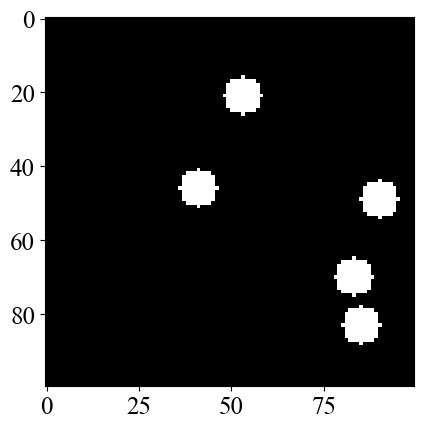

In [3]:
array_size = (100, 100)  # 100x100 array
num_disks = 5            # 5 disks
disk_diameter = 10       # Diameter of 10 pixels

binary_array = generate_binary_disk_array(array_size, num_disks, disk_diameter)

# To visualize the array, you could use matplotlib (optional)
import matplotlib.pyplot as plt
plt.imshow(binary_array, cmap='gray')
plt.show()


In [ ]:
def make_3level_sfmap(x_range, y_range, n_points):
    """Make safety map with 3 levels of hazard."""

    xmin, xmax = x_range
    ymin, ymax = y_range
    x = np.linspace(xmin, xmax, n_points)
    y = np.linspace(ymin, ymax, n_points)
    X, Y = np.meshgrid(x, y)

    sfmap = np.ones((n_points, n_points, 3))

    
    

    return sfmap, (n_points, n_points)